# Two-Tower Retrieval Model

---

## What this notebook does (plain English)

We are building a **product search system** — like Amazon's search bar.

When a user types **"red dress for a wedding"**, the system should return the most relevant products.

We do this with a **Two-Tower model**:
- **Query Tower** — reads a search query and converts it into a small list of numbers (a vector)
- **Product Tower** — reads a product title and converts it into a small list of numbers (a vector)
- We train both towers so that **relevant query-product pairs end up with similar vectors**
- At search time: encode a query → find the nearest product vectors → return those products

```
"red dress"  →  Query Tower  →  [0.2, -0.5, 0.8, ...]  ←── these should be close
"Red Evening Gown"  →  Product Tower  →  [0.3, -0.4, 0.7, ...]

"red dress"  →  Query Tower  →  [0.2, -0.5, 0.8, ...]  ←── these should be far apart
"Car Engine Oil"  →  Product Tower  →  [-0.9, 0.1, -0.2, ...]
```


## PART 1 — Install & Import Libraries


In [28]:
import json


import numpy as np
import pandas as pd
import gc
import warnings
import os

import tensorflow as tf
from tensorflow import keras

from keras.layers import Input
from keras.layers import Embedding
from keras.layers import GlobalAveragePooling1D
from keras.layers import Dense
from keras.layers import Dot
from keras.layers import Lambda

from keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

!pip install faiss-cpu
import faiss

from IPython.display import display

warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', None)

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully!")


TensorFlow version: 2.20.0
All libraries loaded successfully!


In [29]:
!rm -f shopping_queries_dataset_products.parquet* shopping_queries_dataset_examples.parquet* shopping_queries_dataset_sources.csv*

!wget -O shopping_queries_dataset_products.parquet https://media.githubusercontent.com/media/amazon-science/esci-data/main/shopping_queries_dataset/shopping_queries_dataset_products.parquet
!wget -O shopping_queries_dataset_examples.parquet https://media.githubusercontent.com/media/amazon-science/esci-data/main/shopping_queries_dataset/shopping_queries_dataset_examples.parquet
!wget -O shopping_queries_dataset_sources.csv https://raw.githubusercontent.com/amazon-science/esci-data/main/shopping_queries_dataset/shopping_queries_dataset_sources.csv

--2026-09-24 19:50:32--  https://media.githubusercontent.com/media/amazon-science/esci-data/main/shopping_queries_dataset/shopping_queries_dataset_products.parquet
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1108857465 (1.0G) [application/octet-stream]
Saving to: ‘shopping_queries_dataset_products.parquet’

shopping_queries_da 100%[===================>]   1.03G  82.3MB/s    in 16s     

2026-09-24 19:50:47 (68.1 MB/s) - ‘shopping_queries_dataset_products.parquet’ saved [1108857465/1108857465]

--2026-09-24 19:50:47--  https://media.githubusercontent.com/media/amazon-science/esci-data/main/shopping_queries_dataset/shopping_queries_dataset_examples.parquet
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.1

## PART 2 — Load the Data


In [30]:
df_products = pd.read_parquet('shopping_queries_dataset_products.parquet')

df_products = df_products[['product_id', 'product_title']].drop_duplicates()

df_labels = pd.read_parquet(
    'shopping_queries_dataset_examples.parquet'
)

df_dataset = pd.merge(df_labels, df_products, on='product_id')

print("Dataset shape:", df_dataset.shape)
print("\nColumns:", df_dataset.columns.tolist())
print("\nLabel distribution:")
print(df_dataset['esci_label'].value_counts())

df_dataset.head()


Dataset shape: (2679017, 10)

Columns: ['example_id', 'query', 'query_id', 'product_id', 'product_locale', 'esci_label', 'small_version', 'large_version', 'split', 'product_title']

Label distribution:
esci_label
E    1743421
S     588459
I     269488
C      77649
Name: count, dtype: int64


,example_id,query,query_id,product_id,product_locale,esci_label,small_version,large_version,split,product_title
0,0,revent 80 cfm,0,B000MOO21W,us,I,0,1,train,Panasonic FV-20VQ3 WhisperCeiling 190 CFM Ceiling Mounted Fan
1,1,revent 80 cfm,0,B07X3Y6B1V,us,E,0,1,train,"Homewerks 7141-80 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 1.1 Sones, 80 CFM"
2,2,revent 80 cfm,0,B07WDM7MQQ,us,E,0,1,train,"Homewerks 7140-80 Bathroom Fan Ceiling Mount Exhaust Ventilation, 1.5 Sones, 80 CFM, White"
3,3,revent 80 cfm,0,B07RH6Z8KW,us,E,0,1,train,Delta Electronics RAD80L BreezRadiance 80 CFM Heater/Fan/Light Combo White (Renewed)
4,4,revent 80 cfm,0,B07QJ7WYFQ,us,E,0,1,train,Panasonic FV-08VRE2 Ventilation Fan with Recessed LED (Renewed)


In [32]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## PART 3 — Convert Labels & Split Train / Validation


In [33]:
df_dataset['label'] = (df_dataset['esci_label'] == 'E').astype('float32')

train_df = df_dataset[df_dataset['split'] != 'test'].reset_index(drop=True)
val_df   = df_dataset[df_dataset['split'] == 'test'].reset_index(drop=True)

print(f"Training rows   : {len(train_df):,}")
print(f"Validation rows : {len(val_df):,}")
print(f"\nPositive rate (train): {train_df['label'].mean():.2%}")
print(f"Positive rate (val)  : {val_df['label'].mean():.2%}")

train_labels = train_df['label'].values
val_labels   = val_df['label'].values


Training rows   : 2,026,908
Validation rows : 652,109

Positive rate (train): 66.21%
Positive rate (val)  : 61.57%


## PART 4 — Tokenize Raw Text


In [34]:
VOCAB_SIZE      = 50000
MAX_QUERY_LEN   = 10
MAX_PRODUCT_LEN = 30


all_queries  = df_dataset['query'].tolist()
all_products = df_dataset['product_title'].tolist()

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<UNK>')

tokenizer.fit_on_texts(all_queries + all_products)

print(f"Vocabulary size: {len(tokenizer.word_index):,} unique words found")
print(f"We keep the top {VOCAB_SIZE:,} most common ones")


def tokenize_and_pad(texts, max_length):
    word_id_sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences  = pad_sequences(
        word_id_sequences,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )
    return padded_sequences


train_queries  = tokenize_and_pad(train_df['query'].tolist(),         MAX_QUERY_LEN)
train_products = tokenize_and_pad(train_df['product_title'].tolist(), MAX_PRODUCT_LEN)

val_queries    = tokenize_and_pad(val_df['query'].tolist(),           MAX_QUERY_LEN)
val_products   = tokenize_and_pad(val_df['product_title'].tolist(),   MAX_PRODUCT_LEN)


print(f"\nTrain query array shape   : {train_queries.shape}")
print(f"Train product array shape : {train_products.shape}")
print(f"\nExample -- 'red dress for a wedding' tokenized:")
print(tokenize_and_pad(['red dress for a wedding'], MAX_QUERY_LEN)[0])


train_inputs = [train_queries, train_products]
val_inputs   = [val_queries,   val_products]


Vocabulary size: 1,156,672 unique words found
We keep the top 50,000 most common ones

Train query array shape   : (2026908, 10)
Train product array shape : (2026908, 30)

Example -- 'red dress for a wedding' tokenized:
[ 57 132   2  27 218   0   0   0   0   0]


## PART 5 — Build the Two-Tower Model


In [35]:
EMBED_DIM  = 64
OUTPUT_DIM = 16


def build_tower(input_length, name_prefix):

    inp = Input(shape=(input_length,), name=f'input_{name_prefix}')

    word_vectors = Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        name=f'embed_{name_prefix}'
    )(inp)

    sentence_vector = GlobalAveragePooling1D(name=f'pool_{name_prefix}')(word_vectors)

    compressed_vector = Dense(OUTPUT_DIM, activation='linear', name=f'dense_{name_prefix}')(sentence_vector)

    normalized_vector = Lambda(
        lambda v: tf.keras.backend.l2_normalize(v, axis=-1),
        name=f'normalize_{name_prefix}'
    )(compressed_vector)

    return inp, normalized_vector


input_query, output_query = build_tower(MAX_QUERY_LEN, 'query')

input_product, output_product = build_tower(MAX_PRODUCT_LEN, 'product')


similarity_score = Dot(axes=1, normalize=True, name='cosine_similarity')(
    [output_query, output_product]
)


match_score = Lambda(lambda score: (score + 1.0) / 2.0, name='match_score')(similarity_score)

model = Model(
    inputs=[input_query, input_product],
    outputs=match_score,
    name='two_tower_model'
)

model.summary()


Model: "two_tower_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_query         │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_product       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_query         │ (None, 10, 64)    │  3,200,000 │ input_query[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed_product       │ (None, 30, 64)    │  3,200,000 │ input_product[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_query          │ (None, 64)        │          0 │ embed_query[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_product        │ (None, 64)        │          0 │ embed_product[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_query (Dense) │ (None, 16)        │      1,040 │ pool_query[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_product       │ (None, 16)        │      1,040 │ pool_product[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_query     │ (None, 16)        │          0 │ dense_query[0][0] │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalize_product   │ (None, 16)        │          0 │ dense_product[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cosine_similarity   │ (None, 1)         │          0 │ normalize_query[… │
│ (Dot)               │                   │            │ normalize_produc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ match_score         │ (None, 1)         │          0 │ cosine_similarit… │
│ (Lambda)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,402,080 (24.42 MB)

 Trainable params: 6,402,080 (24.42 MB)

 Non-trainable params: 0 (0.00 B)

## PART 6 — Train the Model


In [36]:
CHECKPOINT_PATH = 'best_two_tower.weights.h5'

checkpoint = ModelCheckpoint(
    CHECKPOINT_PATH,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=True,
    mode='min'
)


model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    train_inputs,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_data=(val_inputs, val_labels),
    callbacks=[checkpoint],
    class_weight={0: 1, 1: 3}
)

print("\nTraining complete!")


Epoch 1/10
15836/15836 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6801 - loss: 0.8602
Epoch 1: val_loss improved from None to 0.74486, saving model to best_two_tower.weights.h5

Epoch 1: finished saving model to best_two_tower.weights.h5
15836/15836 ━━━━━━━━━━━━━━━━━━━━ 77s 5ms/step - accuracy: 0.6915 - loss: 0.8191 - val_accuracy: 0.6355 - val_loss: 0.7449
Epoch 2/10
15827/15836 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7190 - loss: 0.7313
Epoch 2: val_loss did not improve from 0.74486
15836/15836 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - accuracy: 0.7198 - loss: 0.7316 - val_accuracy: 0.6372 - val_loss: 0.7536
Epoch 3/10
15835/15836 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7336 - loss: 0.6924
Epoch 3: val_loss improved from 0.74486 to 0.74049, saving model to best_two_tower.weights.h5

Epoch 3: finished saving model to best_two_tower.weights.h5
15836/15836 ━━━━━━━━━━━━━━━━━━━━ 71s 5ms/step - accuracy: 0.7319 - loss: 0.6989 - val_accuracy: 0.6384 - val_loss: 0.7405
Epoch 4/10

In [38]:
model.load_weights(CHECKPOINT_PATH)
print("Best model weights loaded.")


Best model weights loaded.


## PART 7 — Plot Training History


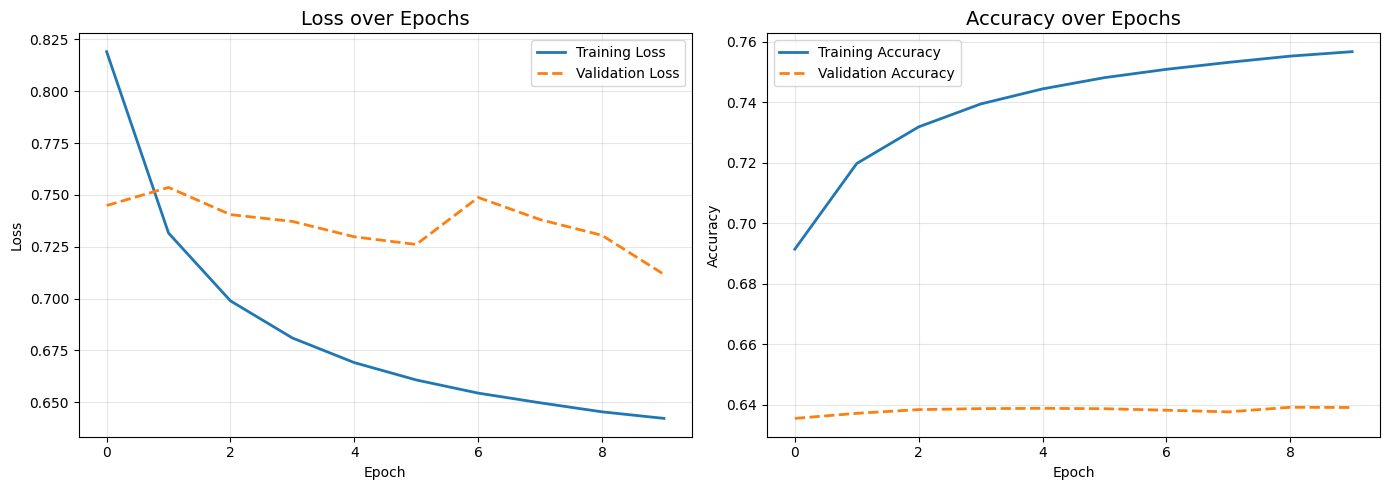

In [39]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'],     label='Training Loss',   linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
ax1.set_title('Loss over Epochs', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'],     label='Training Accuracy',   linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
ax2.set_title('Accuracy over Epochs', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## PART 8 — Extract Product Embeddings


In [37]:
df_all_products = df_dataset[['product_id', 'product_title']].drop_duplicates().reset_index(drop=True)

df_all_products['pid'] = range(len(df_all_products))

print(f"Unique products to embed: {len(df_all_products):,}")


product_tower_model = Model(
    inputs=input_product,
    outputs=model.get_layer('normalize_product').output,
    name='product_tower'
)


all_product_sequences = tokenize_and_pad(
    df_all_products['product_title'].tolist(),
    MAX_PRODUCT_LEN
)

print(f"Product sequences shape: {all_product_sequences.shape}")


product_embeddings = product_tower_model.predict(all_product_sequences, batch_size=512, verbose=1)

print(f"\nProduct embeddings shape: {product_embeddings.shape}")
print("Each product is now represented as a 16-dimensional vector")


Unique products to embed: 1,814,675
Product sequences shape: (1814675, 30)
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step

Product embeddings shape: (1814675, 16)
Each product is now represented as a 16-dimensional vector


In [40]:
embedding_column_names = [f'dim_{i}' for i in range(OUTPUT_DIM)]

df_product_embeddings = pd.DataFrame(product_embeddings, columns=embedding_column_names)

df_product_embeddings['product_id']    = df_all_products['product_id'].values
df_product_embeddings['product_title'] = df_all_products['product_title'].values
df_product_embeddings['pid']           = df_all_products['pid'].values

print("Product embedding table:")
df_product_embeddings.head()


Product embedding table:


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,dim_11,dim_12,dim_13,dim_14,dim_15,product_id,product_title,pid
0,0.165359,0.241640,0.060577,-0.201949,-0.130178,0.119876,-0.106425,-0.622681,-0.187383,0.257165,-0.191740,-0.056608,-0.004394,0.032477,0.534736,0.105869,B000MOO21W,Panasonic FV-20VQ3 WhisperCeiling 190 CFM Ceiling Mounted Fan,0
1,-0.340846,0.254622,-0.116347,-0.162922,0.016872,-0.002487,-0.322842,-0.630637,-0.185020,0.236187,-0.098920,-0.020137,0.128924,-0.183598,0.322532,-0.148749,B07X3Y6B1V,"Homewerks 7141-80 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 1.1 Sones, 80 CFM",1
2,-0.296006,0.198002,-0.087979,-0.196732,-0.015535,-0.003638,-0.306120,-0.649852,-0.181887,0.258389,-0.038606,-0.014173,0.098423,-0.204828,0.392359,-0.057731,B07WDM7MQQ,"Homewerks 7140-80 Bathroom Fan Ceiling Mount Exhaust Ventilation, 1.5 Sones, 80 CFM, White",2
3,-0.288533,0.495957,-0.123921,-0.284820,-0.408282,-0.121713,-0.197618,-0.466869,-0.113570,0.168398,-0.039945,0.013160,-0.072825,-0.111435,0.262296,0.078886,B07RH6Z8KW,Delta Electronics RAD80L BreezRadiance 80 CFM Heater/Fan/Light Combo White (Renewed),3
4,-0.131070,0.189409,-0.090300,-0.143492,-0.299944,-0.090423,-0.424817,-0.593672,-0.301381,0.203678,0.019853,-0.068943,-0.038255,-0.332203,0.132630,-0.142361,B07QJ7WYFQ,Panasonic FV-08VRE2 Ventilation Fan with Recessed LED (Renewed),4


## PART 9 — Build the Product Search Index (FAISS)


In [41]:
product_search_index = faiss.IndexFlatIP(OUTPUT_DIM)

index_to_pid = df_product_embeddings['pid'].tolist()

index_to_pid_as_ints = []
for x in index_to_pid:
    index_to_pid_as_ints.append(int(x))

with open('index_to_pid.json', 'w') as f:
    json.dump(index_to_pid_as_ints, f)
print("Saved: index_to_pid.json")

pid_to_title      = {}
pid_to_product_id = {}

for _, row in df_product_embeddings.iterrows():
    pid = int(row['pid'])
    pid_to_title[pid]      = row['product_title']
    pid_to_product_id[pid] = row['product_id']

vectors = df_product_embeddings[embedding_column_names].values.astype('float32')

faiss.normalize_L2(vectors)

product_search_index.add(vectors)
print(f"Added {product_search_index.ntotal:,} product vectors to FAISS index")

faiss.write_index(product_search_index, 'product_search_index.faiss')
print("Saved: product_search_index.faiss")

product_search_index = faiss.read_index('product_search_index.faiss')
print("FAISS product search index ready!")


Saved: index_to_pid.json
Added 1,814,675 product vectors to FAISS index
Saved: product_search_index.faiss
FAISS product search index ready!


## PART 10 — Quality Check: Are Similar Products Close Together?


In [42]:

TOP_K         = 5
ROWS_TO_CHECK = 10

results = []

for i in range(ROWS_TO_CHECK):
    row = df_product_embeddings.iloc[i]
    pid           = int(row.pid)
    product_title = row.product_title

    raw_vec = df_product_embeddings[embedding_column_names].iloc[i].values
    vec = raw_vec.astype('float32').reshape(1, -1)

    faiss.normalize_L2(vec)

    _, neighbor_index_array = product_search_index.search(vec, TOP_K + 1)
    neighbor_indices = neighbor_index_array[0]

    nearest_titles = []
    for faiss_row_idx in neighbor_indices:
        if faiss_row_idx == -1:
            continue

        real_pid = int(index_to_pid[faiss_row_idx])

        if real_pid == pid:
            continue

        nearest_titles.append(pid_to_title.get(real_pid, 'UNKNOWN'))

        if len(nearest_titles) == TOP_K:
            break

    results.append([product_title] + nearest_titles)

columns = ['product']
for i in range(TOP_K):
    columns.append(f'similar_{i+1}')

df_quality_check = pd.DataFrame(results, columns=columns)

print("Product similarity quality check:")
print("(Each row shows a product and its 5 most similar products)")
display(df_quality_check)


Product similarity quality check:
(Each row shows a product and its 5 most similar products)


,product,similar_1,similar_2,similar_3,similar_4,similar_5
0,Panasonic FV-20VQ3 WhisperCeiling 190 CFM Ceiling Mounted Fan,"4K@60Hz HDMI Switch Splitter 2 in 4 Out with Remote, avedio links 2x4 HDMI Splitter Switcher 4K with SPDIF & 3.5mm Audio,Support 4K,3D,1080p,HDCP2.2,HDR 10 for PS4,Xbox,Fire Stick,etc","Notebook: Beach Fun , Journal for Writing, College Ruled Size 6"" x 9"", 110 Pages","Notebook: Seel , Journal for Writing, College Ruled Size 6"" x 9"", 110 Pages","Notebook: Chappie , Journal for Writing, College Ruled Size 6"" x 9"", 110 Pages","The Spirit of Flight Journal (Notebook, Diary) (Oversized Journal) (Journals)"
1,"Homewerks 7141-80 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 1.1 Sones, 80 CFM","Homewerks 7140-80 Bathroom Fan Ceiling Mount Exhaust Ventilation, 1.5 Sones, 80 CFM, White","Homewerks 7141-50 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 0.7 Sones, 50 CFM","Homewerks 7117-01-BN Bathroom Integrated LED Light Ceiling Mount Exhaust Ventilation 1.1 Sones 80 CFM, Bath Fan Brushed Nickel","Homewerks 7141-110 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 2.0 Sones, 110 CFM",Doraking A5 Size Frosted Transparent PP Loose-leaf Spiral Refillable Notebook with 4 Colored Index Pages Dividers(Pink)
2,"Homewerks 7140-80 Bathroom Fan Ceiling Mount Exhaust Ventilation, 1.5 Sones, 80 CFM, White","Homewerks 7107-03HW Bathroom Fan Ceiling Mount Exhaust Ventilation 1.0 Sones, 110 CFM, Energy Star, White","Homewerks 7141-80 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 1.1 Sones, 80 CFM","Homewerks 7141-110 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 2.0 Sones, 110 CFM","Homewerks 7140-50 Bathroom Fan Ceiling Mount Exhaust Ventilation, 1.5 Sones, 50 CFM, White","Homewerks 7141-50 Bathroom Fan Integrated LED Light Ceiling Mount Exhaust Ventilation, 0.7 Sones, 50 CFM"
3,Delta Electronics RAD80L BreezRadiance 80 CFM Heater/Fan/Light Combo White (Renewed),Unisex Synthetic Short Straight Bob Hair Adult Lolita Cosplay Costume Wig Halloween (Light Brown),"nuLOOM Contemporary Sherill Wind Area Rug, 3' x 5', Grey","SAFAVIEH Amherst Collection AMT422P Moroccan Trellis Non-Shedding Living Room Bedroom Accent Area Rug, 3' x 5', Navy / Beige",S-noilite Unisex Short Light Blue Cosplay Costume Wigs for Women Mens Male Anime Comic Shaggy Pixie Fluffy Straight Synthetic Hair Full Wig Halloween Party Fancy Dress,YUANDAN 100% Polyester The Dude You Eat The Last Unicorn Dinosaurs Adult Chef Apron
4,Panasonic FV-08VRE2 Ventilation Fan with Recessed LED (Renewed),"Race Ramps RR-ROCK-6-FS 6"" H Show Rock (Fieldstone Gray)",Halloween Pumpkin Sticker 28pcs Pumpkin Decorating Stickers for Kids Halloween Pumpkin Face Craft,Panasonic FV-08VRE2 Ventilation Fan with Recessed LED,Foam Pumpkin Decorating Craft Kit -12 - Crafts for Kids and Fun Home Activities,CE265A Toner Collection Unit for HP CP4525 4025 CM4540 M651 M680 Waste Toner Box
5,"Panasonic FV-0511VQ1 WhisperCeiling DC Ventilation Fan, Speed Selector, SmartFlow Technology, Quiet,White","Kelme Charles, Zapatillas Mujer, Beige (Maquillaje/Red), 38 EU",EVGA Intel Z170 Classified 4-Way lga1151-atx Placa Base,Vaselina Original de Jalea de petróleo puro (2 x 50 ML),Relion Glucose Tablets - Tropical Flavor - 50 Counts (2 Pack),"Ubiquiti Networks UniFi AC In‑Wall Pro Wi-Fi Access Point - Punto de Acceso (1300 Mbit/s, IEEE 802.3at, 10,100,1000 Mbit/s, 1300 Mbit/s, AES,TKIP,WEP,WPA-Enterprise,WPA-PSK,WPA2, Integrated Antenna)"
6,"Panasonic FV-0510VSL1 WhisperValue DC Ventilation Fan with Light, 50-80-100 CFM","Panasonic FV-0510VS1 WhisperValue DC Ventilation Fan, 50-80-100 CFM","Panasonic FV-0511VQCL1 WhisperSense DC Ventilation Fan with Light, 50-80-110 CFM","Panasonic FV-0510VSC1 WhisperValue DC Ventilation Fan with Built-in Condensation Sensor, 50-80-100 CFM","Panasonic FV-0810VSS1 WhisperValue DC Ventilation Fan, 80 or 100 CFM","Panasonic FV-1115VQL1 WhisperCeiling DC Ventilation

## PART 11 — Create a Query Tower Sub-Model


In [43]:
query_tower_model = Model(
    inputs=input_query,
    outputs=model.get_layer('normalize_query').output,
    name='query_tower'
)

print("Query Tower sub-model ready!")
query_tower_model.summary()


Query Tower sub-model ready!


Model: "query_tower"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_query (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed_query (Embedding)         │ (None, 10, 64)         │     3,200,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_query                      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_query (Dense)             │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalize_query (Lambda)        │ (None, 16)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201,040 (12.21 MB)

 Trainable params: 3,201,040 (12.21 MB)

 Non-trainable params: 0 (0.00 B)

## PART 12 — Search Function


In [44]:
def search(query_text, top_k=10):

    word_id_list  = tokenizer.texts_to_sequences([query_text])
    padded_query  = pad_sequences(
        word_id_list,
        maxlen=MAX_QUERY_LEN,
        padding='post',
        truncating='post'
    )

    query_embedding = query_tower_model.predict(padded_query, verbose=0)[0]

    query_vec_f32 = query_embedding.reshape(1, -1).astype('float32')

    faiss.normalize_L2(query_vec_f32)

    distances_array, row_indices_array = product_search_index.search(query_vec_f32, top_k)

    distances  = distances_array[0]
    faiss_rows = row_indices_array[0]

    results = []
    rank = 1

    total_results = len(faiss_rows)

    for i in range(total_results):

        faiss_row  = faiss_rows[i]
        similarity = distances[i]

        if faiss_row == -1:
            continue

        real_pid = int(index_to_pid[faiss_row])

        title = pid_to_title.get(real_pid, 'UNKNOWN')

        similarity_rounded = round(float(similarity), 4)

        one_result = {
            'rank'            : rank,
            'product_title'   : title,
            'similarity_score': similarity_rounded
        }

        results.append(one_result)

        rank = rank + 1

    return pd.DataFrame(results)


print("Search function is ready!")
print("Usage: search('your query here', top_k=10)")


Search function is ready!
Usage: search('your query here', top_k=10)


## PART 13 — Run Searches!


In [45]:
test_queries = [
    "red dress for a wedding",
    "best laptop under 1000",
    "nike running shoes for women",
    "bluetooth earbuds under 50",
    "organic skincare products",
    "gaming laptop with rtx graphics",
    "winter jacket for men",
    "coffee maker"
]

TOP_K = 5

for query in test_queries:
    print(f"\n{'='*60}")
    print(f"Query: '{query}'")
    print(f"{'='*60}")
    results_df = search(query, top_k=TOP_K)
    display(results_df)



Query: 'red dress for a wedding'


,rank,product_title,similarity_score
0,1,"Arrowhead Mountain Spring Water, 8 Oz (Carton of 48)",0.9162
1,2,"Secret Wishes womens Secret Wishes Dark Rose Costume Dress Party Supplies, As Shown, Large US",0.9118
2,3,"Red DO NOT Enter Directional Traffic Yard Sign 24"" x 18"" Lawn Signage w/Metal Stake",0.8960
3,4,Vintage I’m Not Old I’m A Classic 1957 T-Shirt,0.8913
4,5,シール 50枚 Rickton フレークシール シールノート ステッカー 和紙 可愛いシール シール手帳 シールブック 日記シール カレンダー お手紙用 スマホケース用 50枚シールノート (Dreams like rainbow),0.8826



Query: 'best laptop under 1000'


,rank,product_title,similarity_score
0,1,"Adorox (6 x 3.5 x 3.25, Assorted 24Pk) Large Lightweight Assorted Bright Rainbow Colors Cardboard Favor Boxes Treat Goody Bags Birthday Party Event Gift",0.9873
1,2,PlayStation 2 (ミッドナイトブルー) BB Pack (SCPH-50000MB/NH) 【メーカー生産終了】,0.9871
2,3,"CleverMade Collapsible Cooler Bag with Shoulder Strap: Insulated Leakproof 30 Can Portable Soft Beverage Tote with Bottle Opener for Camping, Lunch, Beach, Picnic; Grey/Charcoal",0.9841
3,4,"18-in-1 Snowflake Multi-tool, Stainless Combination Compact Portable Outdoor Products Tool Card Keychain Bottle Opener (Black)",0.9839
4,5,"Scallop Stem Cup - Parfait Serving Bowl - 24 Count - Clear Hard Plastic - Appetizer Cup - Disposable or Reusable - 2 ounce - Ideal for Desserts, Appetizers, Puddings",0.9835



Query: 'nike running shoes for women'


...

,rank,product_title,similarity_score
0,1,Samsung QN65LS03TA The Frame 3.0 65-inch QLED Smart 4K UHD TV (2020 Model) Bundle with Samsung VG-SCFT65WT/ZA (2020) 65-inch The Frame Customizable Bezel - White,0.9120
1,2,Samsung The Frame QE65LS03A 65 pulgadas 4K Ultra HD HDR Smart QLED TV,0.9107
2,3,SAMSUNG QN65LS03A / QN65LS03AA / QN65LS03AA 65 inch The Frame QLED 4K Smart TV (Renewed),0.9102
3,4,Newest 2021 MSI Gaming GeForce RTX 3060 12GB 15 Gbps GDRR6 192-Bit HDMI/DP PCIe 4 Tri-Frozr Torx Fan Ampere RGB OC Graphics Card (RTX 3060 Gaming X Trio 12G) +AllyFlex HDMI,0.9035
4,5,Samsung QN65LS03AAFXZA 65 Inch The Frame QLED 4K Smart TV 2021 Bundle with Samsung 2021 65 inch The Frame Customizable Bezel Modern Teak,0.9025



Query: 'winter jacket for men'


,rank,product_title,similarity_score
0,1,"Cole Haan Signature Men's Diamond Quilted Jacket with Faux Sherpa Lining, Black, Medium",0.9593
1,2,"PUREMSX Men's Plus Size Quilted Parka Jacket Casual Heavyweight Warm Arctic Cloth Quilted Anorak Coat with Tan Faux Fur-Trimmed Hood for Winter Puffer Jacket Winter Classy Coats,Black,XX-Large",0.9575
2,3,"BB Dakota by Steve Madden Women's Gabrielle Vegan Leather Jacket, Black, Medium",0.9538
3,4,"Honor 8X 16,5 cm (6.5"") 4 GB 128 GB SIM doble 4G Negro 3750 mAh - Smartphone (16,5 cm (6.5""), 4 GB, 128 GB, 20 MP, Android 8.1, Negro)",0.9526
4,5,TBMPOY Men's Full-Zip Fleece Jacket Soft Polar Winter Outdoor Coat with Pockets Wine Red/Gray XXL,0.9513



Query: 'coffee maker'


,rank,product_title,similarity_score
0,1,LG NeoChef 2.0 Cu. Ft. Countertop Microwave in Stainless Steel Black Stainless Steel,0.9802
1,2,"Alfred's Essentials of Music Theory: Complete, Book & 2 CDs (Essentials of Music Theory) (Paperback) - Common",0.9786
2,3,"K&F Concept 49mm ND8 Lens Filter and CPL Circular Polarizing Filter 2 in 1 for Camera Lens with 28 Multi-Layer Coatings, Hydrophobic, Scratch Resistant",0.9772
3,4,FranklinCovey Classic Her Point of View Daily Ring-Bound Planner - Jan 2020 - Dec 2020,0.9765
4,5,FranklinCovey Classic Monticello One-Page-Per-Day Ring-Bound Planner - Jan 2020 - Dec 2020,0.9749


## PART 14 — Save Everything for Later Use


In [46]:
import json

tokenizer_as_json = tokenizer.to_json()
with open('tokenizer_config.json', 'w') as f:
    f.write(tokenizer_as_json)
print("Saved: tokenizer_config.json")


query_tower_model.save('query_tower.h5')
print("Saved: query_tower.h5")


product_tower_model.save('product_tower.h5')
print("Saved: product_tower.h5")


df_all_products.to_csv('product_metadata.csv', index=False)
print("Saved: product_metadata.csv")


print("\nAll files saved! To use this system later:")
print("1. Load tokenizer from tokenizer_config.json")
print("2. Load query_tower.h5")
print("3. Load product_search_index.faiss")
print("4. Load product_metadata.csv for title lookups")
print("5. Call search(query_text) to search!")


Saved: tokenizer_config.json
Saved: query_tower.h5
Saved: product_tower.h5
Saved: product_metadata.csv

All files saved! To use this system later:
1. Load tokenizer from tokenizer_config.json
2. Load query_tower.h5
3. Load product_search_index.faiss
4. Load product_metadata.csv for title lookups
5. Call search(query_text) to search!


## Summary — Full System Flow

---

Here's the complete picture:

```
TRAINING TIME:

Raw query text  ──►  Tokenizer  ──►  [45, 231, 0, ...]  ──►  Query Tower  ──►  [0.2, -0.5, ...]  (16D)
                                                                                                        \
                                                                                             Cosine Sim  ──►  Match score (0 to 1)
                                                                                                        /
Raw product text ──►  Tokenizer  ──►  [12, 88, 44, ...]  ──►  Product Tower ──►  [0.3, -0.4, ...]  (16D)

Match score = (cosine similarity + 1) / 2
Loss compares this score with the true label (1=relevant, 0=not relevant)
Optimizer adjusts weights to reduce loss


SEARCH TIME:

New query text ──►  Tokenizer  ──►  Query Tower  ──►  16D vector
                                                            |
                                                    FAISS Index Search
                                                            |
                                               Top-K nearest product vectors
                                                            |
                                                   Return product titles ✅
```

| Part | What it does |
|------|--------------|
| 1 | Import libraries |
| 2 | Load and merge data |
| 3 | Convert labels to binary, split train/val |
| 4 | **Tokenize raw text** (word → integer ID, pad to fixed length) |
| 5 | **Build Two-Tower model** (Embedding → Pool → Dense → Normalize → Cosine Similarity → Match Score) |
| 6 | Train the model |
| 7 | Plot training history |
| 8 | Extract 16-dim embeddings for all products |
| 9 | Build FAISS search index from product embeddings |
| 10 | Quality check: are similar products near each other? |
| 11 | Create Query Tower sub-model |
| 12 | `search()` function |
| 13 | Run test searches |
| 14 | Save everything |
